In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [4]:
import solve
import aux_ as aux
import RANK
import linear
import neural_nets
import model_funcs

# Device

In [5]:
device = aux.choose_gpu()

choosing cpu


# Load solutions

In [6]:
ZLB_sol_path = 'output/nn_ZLB_29_4.pkl'
noZLB_sol_path = 'output/nn_noZLB_29_4.pkl'

In [7]:
model = RANK.RANK_model(device)
model.load(ZLB_sol_path)

model_noZLB = RANK.RANK_model(device)
model_noZLB.load(noZLB_sol_path, opt_load=False)

# IRFs

In [8]:
shock_std = (0.0082, 0.0044, 0.0097)

#shock_std = (2*0.0082, 2*0.0044, 2*0.0097)

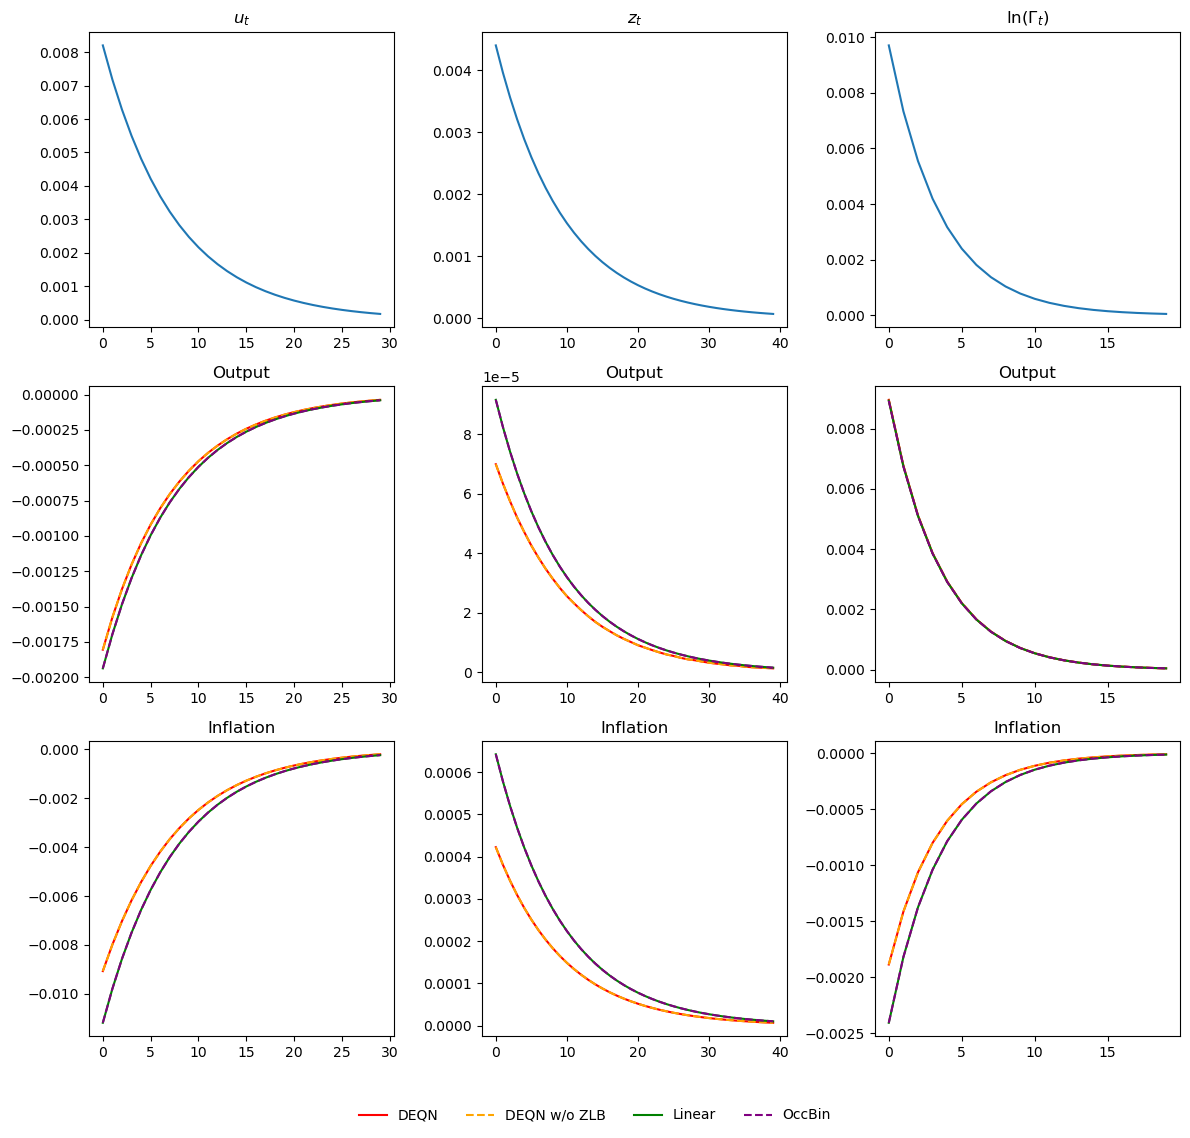

In [9]:
model.compute_IRF(shock_std, extra_nn=model_noZLB.nn)
model.plot_IRF(plot_extra=True, save_path='plots/IRFs.png')

# GIRFs

In [10]:
model.compute_GIRF(shock_std, 10000, extra_nn=model_noZLB.nn)

In [11]:
shock_std = (0.0082, 0.0044, 0.0097)

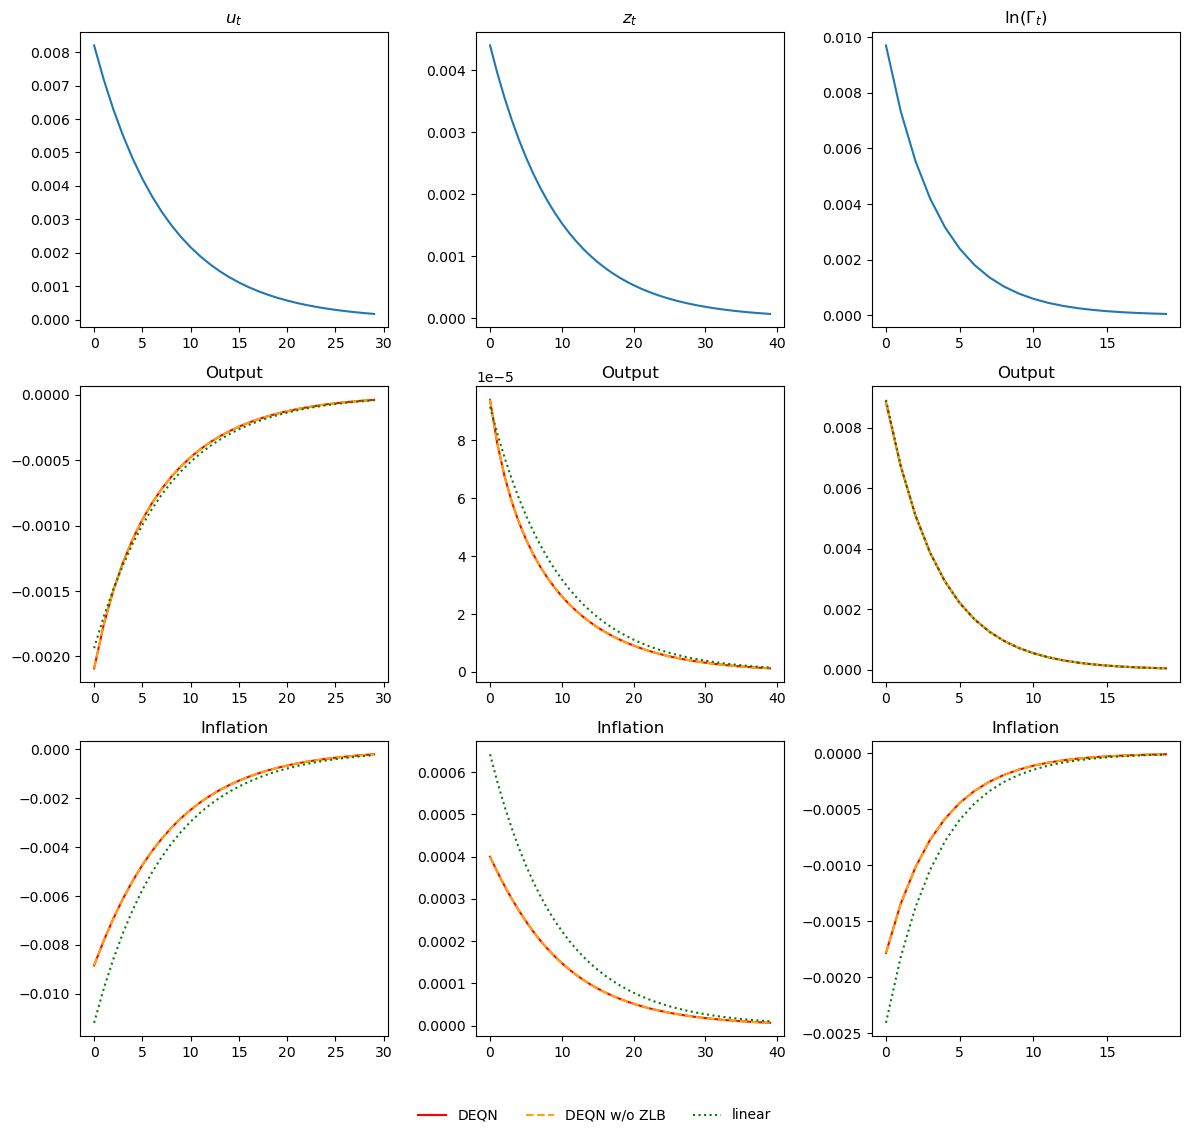

In [12]:
model.plot_GIRF(plot_extra=True, save_path='plots/GIRFs.png', plot_OccBin=False)

# Simulation ($N=1, T=70$)

In [13]:
solve.simulate(model, 70, (0.0082, 0.0044, 0.0097), extra_nn=model_noZLB.nn)

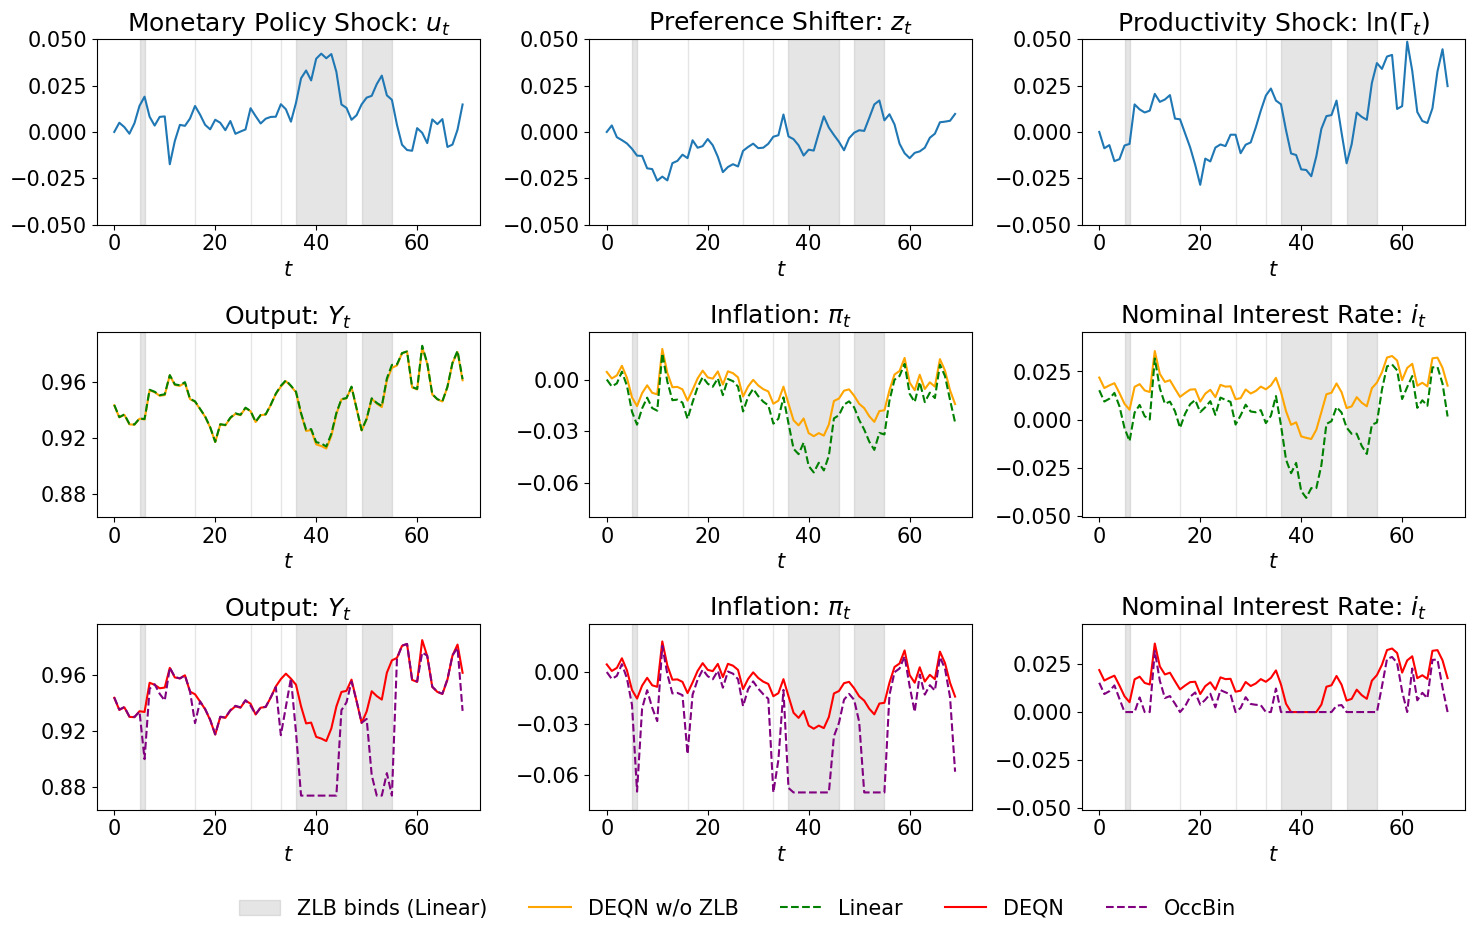

In [14]:
import matplotlib.ticker as mticker
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(3,3, figsize=(15,10))

ax[0,0].plot(model.sim.states[:, 0])
ax[0,0].set_title(r'Monetary Policy Shock: $u_t$')

ax[0,1].plot(model.sim.states[:, 1])
ax[0,1].set_title(r'Preference Shifter: $z_t$')

ax[0,2].plot(model.sim.states[:, 2])
ax[0,2].set_title(r'Productivity Shock: $\ln(\Gamma_t)$')

for i in range(3):
    ax[0,i].set_ylim([-0.05, 0.05])

ax[1,0].plot(model.sim.Y_extra, label='DEQN w/o ZLB', color='orange')
ax[1,0].plot(model.sim.Y_lin, label='Linear', ls = '--', color='green')

ax[1,1].plot(model.sim.pi_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,1].plot(model.sim.pi_lin, ls='--', color='green') #, label='Linear', ls = '--')

ax[1,2].plot(model.sim.i_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,2].plot(model.sim.i_lin, ls='--', color='green') # label='Linear', ls = '--')

ax[2,0].plot(model.sim.Y, label='DEQN', color='red')
ax[2,0].plot(model.sim.Y_OccBin, label='OccBin', ls='--', color='purple')

ax[2,1].plot(model.sim.pi, color='red') #, label='DEQN')
ax[2,1].plot(model.sim.pi_OccBin, ls='--', color='purple') #, label='OccBin', ls='--')

ax[2,2].plot(model.sim.i, color='red') #, label='DEQN')
ax[2,2].plot(model.sim.i_OccBin, ls='--', color='purple') # label='OccBin', ls='--')

#
Ys_ = jnp.stack([model.sim.Y, model.sim.Y_lin, model.sim.Y_extra, model.sim.Y_OccBin])
pis_ = jnp.stack([model.sim.pi, model.sim.pi_lin, model.sim.pi_extra, model.sim.pi_OccBin])
is_ = jnp.stack([model.sim.i, model.sim.i_lin, model.sim.i_extra, model.sim.i_OccBin])

for i in range(1,3):
    ax[i,0].set_ylim([Ys_.min()-0.01, Ys_.max()+0.01])
    ax[i,1].set_ylim([pis_.min()-0.01, pis_.max()+0.01])
    ax[i,2].set_ylim([is_.min()-0.01, is_.max()+0.01])

#
for i in range(3):
    for j in range(1,3):

        ax[j,0].set_title(r'Output: $Y_t$')
        ax[j,1].set_title(r'Inflation: $\pi_t$')
        ax[j,2].set_title(r'Nominal Interest Rate: $i_t$')

zlb_mask = model.sim.i_lin < 0

label_add = True
for i in range(3):
    for j in range(3):
        
        if label_add:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                             ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                             where=zlb_mask, 
                             color='gray', alpha=0.2, label='ZLB binds (Linear)')
            label_add = False

        else:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                        ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                        where=zlb_mask, 
                        color='gray', alpha=0.2)

for i in range(3):
    for j in range(3):
        ax[j,i].set_xlabel('$t$')
        ax[i,j].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4)) # nbins=4 giver præcis 5 ticks

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

f.savefig('plots/Simulation_Example.png')

In [15]:
model.sim.i_lin.min()

Array(-0.04068768, dtype=float32)

In [16]:
model.sim.i_extra[41]

Array(-0.00950205, dtype=float32)

# Simulation ($N=10000, T=1$)

In [17]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

In [18]:
key = jax.random.key(42)

N = 100_000

states = aux.draw_states_directly(key, model.par, jnp.float32, N, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, states, N)
i = model_funcs.taylor_rule(model.par, Y, pi, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

Y_extra, pi_extra = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, states, N)
i_extra = model_funcs.taylor_rule(model.par, Y_extra, pi_extra, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

Y_DSS = model.par["Y_DSS"]
out_OccBin, _ = linear.OccBin(model.par, model.linear, states)
Y_OccBin = jnp.clip(out_OccBin[:, 0], -0.07, 1)
pi_OccBin = jnp.clip(out_OccBin[:, 1], -0.07, 1)
i_OccBin = model_funcs.taylor_rule(model.par, Y_DSS + Y_OccBin, pi_OccBin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

out_lin = states @ model.linear["P"].T
Y_lin = out_lin[:, 0]
pi_lin = out_lin[:, 1]
i_lin = model_funcs.taylor_rule(model.par, Y_DSS + Y_lin, pi_lin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

In [19]:
print(f'Y\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[Y]\t{jnp.mean(Y_DSS+Y_lin):.4f}\t{jnp.mean(Y_DSS+Y_OccBin):.4f}\t\t{jnp.mean(Y_extra):.4f}\t{jnp.mean(Y):.4f}')
print(f'std[Y]\t{jnp.std(Y_DSS+Y_lin):.4f}\t{jnp.std(Y_DSS+Y_OccBin):.4f}\t\t{jnp.std(Y_extra):.4f}\t{jnp.std(Y):.4f}')
print(f'min[Y]\t{jnp.min(Y_DSS+Y_lin):.4f}\t{jnp.min(Y_DSS+Y_OccBin):.4f}\t\t{jnp.min(Y_extra):.4f}\t{jnp.min(Y):.4f}')
print(f'max[Y]\t{jnp.max(Y_DSS+Y_lin):.4f}\t{jnp.max(Y_DSS+Y_OccBin):.4f}\t\t{jnp.max(Y_extra):.4f}\t{jnp.max(Y):.4f}')

print(f'\npi\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[pi]\t{jnp.mean(pi_lin):.4f}\t{jnp.mean(pi_OccBin):.4f}\t\t{jnp.mean(pi_extra):.4f}\t{jnp.mean(pi):.4f}')
print(f'std[pi]\t{jnp.std(pi_lin):.4f}\t{jnp.std(pi_OccBin):.4f}\t\t{jnp.std(pi_extra):.4f}\t{jnp.std(pi):.4f}')
print(f'min[pi]\t{jnp.min(pi_lin):.4f}\t{jnp.min(pi_OccBin):.4f}\t\t{jnp.min(pi_extra):.4f}\t{jnp.min(pi):.4f}')
print(f'max[pi]\t{jnp.max(pi_lin):.4f}\t{jnp.max(pi_OccBin):.4f}\t\t{jnp.max(pi_extra):.4f}\t{jnp.max(pi):.4f}')

print(f'\ni\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[i]\t{jnp.mean(i_lin):.4f}\t{jnp.mean(i_OccBin):.4f}\t\t{jnp.mean(i_extra):.4f}\t{jnp.mean(i):.4f}')
print(f'std[i]\t{jnp.std(i_lin):.4f}\t{jnp.std(i_OccBin):.4f}\t\t{jnp.std(i_extra):.4f}\t{jnp.std(i):.4f}')
print(f'min[i]\t{jnp.min(i_lin):.4f}\t{jnp.min(i_OccBin):.4f}\t\t{jnp.min(i_extra):.4f}\t{jnp.min(i):.4f}')
print(f'max[i]\t{jnp.max(i_lin):.4f}\t{jnp.max(i_OccBin):.4f}\t\t{jnp.max(i_extra):.4f}\t{jnp.max(i):.4f}')

Y	Linear	OccBin		DEQN-	DEQN
E[Y]	0.9438	0.9347		0.9434	0.9434
std[Y]	0.0134	0.0254		0.0134	0.0134
min[Y]	0.8845	0.8738		0.8845	0.8845
max[Y]	1.0065	1.0065		1.0069	1.0069

pi	Linear	OccBin		DEQN-	DEQN
E[pi]	0.0000	-0.0052		0.0059	0.0059
std[pi]	0.0235	0.0321		0.0195	0.0195
min[pi]	-0.1099	-0.0700		-0.0907	-0.0907
max[pi]	0.1108	0.1108		0.1174	0.1174

i	Linear	OccBin		DEQN-	DEQN
E[i]	0.0148	0.0179		0.0237	0.0237
std[i]	0.0211	0.0167		0.0152	0.0151
min[i]	-0.0907	0.0000		-0.1152	0.0000
max[i]	0.1094	0.1094		0.1215	0.1215


In [20]:
# En lille hjælpefunktion til at beregne skewness (skævhed)
def skewness(x):
    return jnp.mean(((x - jnp.mean(x)) / jnp.std(x))**3)

# Beregninger for Y
print(f'Y\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[Y]\t{jnp.mean(Y_DSS+Y_lin):.4f}\t{jnp.mean(Y_DSS+Y_OccBin):.4f}\t\t{jnp.mean(Y_extra):.4f}\t{jnp.mean(Y):.4f}')
print(f'std[Y]\t{jnp.std(Y_DSS+Y_lin):.4f}\t{jnp.std(Y_DSS+Y_OccBin):.4f}\t\t{jnp.std(Y_extra):.4f}\t{jnp.std(Y):.4f}')
print(f'med[Y]\t{jnp.median(Y_DSS+Y_lin):.4f}\t{jnp.median(Y_DSS+Y_OccBin):.4f}\t\t{jnp.median(Y_extra):.4f}\t{jnp.median(Y):.4f}')
print(f'ske[Y]\t{skewness(Y_DSS+Y_lin):.4f}\t{skewness(Y_DSS+Y_OccBin):.4f}\t\t{skewness(Y_extra):.4f}\t{skewness(Y):.4f}')

# Beregninger for pi
print(f'\npi\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[pi]\t{jnp.mean(pi_lin):.4f}\t{jnp.mean(pi_OccBin):.4f}\t\t{jnp.mean(pi_extra):.4f}\t{jnp.mean(pi):.4f}')
print(f'std[pi]\t{jnp.std(pi_lin):.4f}\t{jnp.std(pi_OccBin):.4f}\t\t{jnp.std(pi_extra):.4f}\t{jnp.std(pi):.4f}')
print(f'med[pi]\t{jnp.median(pi_lin):.4f}\t{jnp.median(pi_OccBin):.4f}\t\t{jnp.median(pi_extra):.4f}\t{jnp.median(pi):.4f}')
print(f'ske[pi]\t{skewness(pi_lin):.4f}\t{skewness(pi_OccBin):.4f}\t\t{skewness(pi_extra):.4f}\t{skewness(pi):.4f}')

# Beregninger for i
print(f'\ni\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[i]\t{jnp.mean(i_lin):.4f}\t{jnp.mean(i_OccBin):.4f}\t\t{jnp.mean(i_extra):.4f}\t{jnp.mean(i):.4f}')
print(f'std[i]\t{jnp.std(i_lin):.4f}\t{jnp.std(i_OccBin):.4f}\t\t{jnp.std(i_extra):.4f}\t{jnp.std(i):.4f}')
print(f'med[i]\t{jnp.median(i_lin):.4f}\t{jnp.median(i_OccBin):.4f}\t\t{jnp.median(i_extra):.4f}\t{jnp.median(i):.4f}')
print(f'ske[i]\t{skewness(i_lin):.4f}\t{skewness(i_OccBin):.4f}\t\t{skewness(i_extra):.4f}\t{skewness(i):.4f}')

Y	Linear	OccBin		DEQN-	DEQN
E[Y]	0.9438	0.9347		0.9434	0.9434
std[Y]	0.0134	0.0254		0.0134	0.0134
med[Y]	0.9438	0.9404		0.9434	0.9434
ske[Y]	0.0003	-1.2407		0.0078	0.0078

pi	Linear	OccBin		DEQN-	DEQN
E[pi]	0.0000	-0.0052		0.0059	0.0059
std[pi]	0.0235	0.0321		0.0195	0.0195
med[pi]	0.0000	0.0000		0.0042	0.0042
ske[pi]	0.0054	-0.7032		0.4876	0.4876

i	Linear	OccBin		DEQN-	DEQN
E[i]	0.0148	0.0179		0.0237	0.0237
std[i]	0.0211	0.0167		0.0152	0.0151
med[i]	0.0152	0.0152		0.0214	0.0214
ske[i]	-0.0857	0.7591		0.7757	0.7898


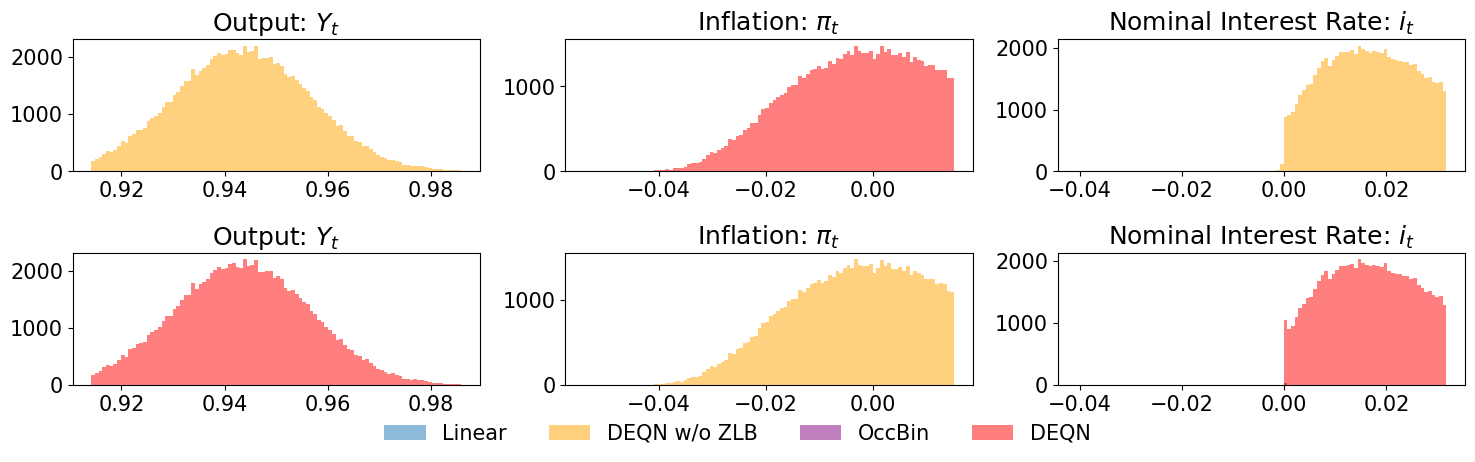

In [21]:
#maximum observations
data_max = max(model.sim.Y_OccBin.max(), model.sim.Y_lin.max())
sh_bins = np.linspace(model.sim.Y_lin.min(), data_max, 101)

f, ax = plt.subplots(2,3, figsize=(15,5))
ax[0,0].hist(model.sim.Y_lin.flatten(), bins=sh_bins, alpha=0.5, label='Linear')
ax[0,0].hist(Y_extra.flatten(), bins=sh_bins, alpha=0.5, label='DEQN w/o ZLB', color='orange')

ax[1,0].hist(model.sim.Y_OccBin.flatten(), bins=sh_bins, alpha=0.5, label='OccBin', color='purple')
ax[1,0].hist(Y.flatten(), bins=sh_bins, alpha=0.5, label='DEQN', color='red')

data_max = max(model.sim.pi_OccBin.max(), model.sim.pi_lin.max())
sh_bins = np.linspace(model.sim.pi_lin.min(), data_max, 101)

ax[0,1].hist(model.sim.pi_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[1,1].hist(pi_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,1].hist(model.sim.pi_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[0,1].hist(pi.flatten(), bins=sh_bins, alpha=0.5, color='red')

data_max = max(model.sim.i_OccBin.max(), model.sim.i_lin.max())
sh_bins = np.linspace(model.sim.i_lin.min(), data_max, 101)

ax[0,2].hist(model.sim.i_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[0,2].hist(i_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,2].hist(model.sim.i_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[1,2].hist(i.flatten(), bins=sh_bins, alpha=0.5, color='red')

for i_ in range(2):
    ax[i_,0].set_title(r'Output: $Y_t$')
    ax[i_,1].set_title(r'Inflation: $\pi_t$')
    ax[i_,2].set_title(r'Nominal Interest Rate: $i_t$')

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

# f.savefig('Ergodic_distribution_lin_OccBin.png')

# Simulation ($N=1, T=1000$)

In [22]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

In [23]:
key = jax.random.key(42)

T = 100_000

key, subkey = jax.random.split(key)
eps = aux.draw_shocks(subkey, model.dtype, T, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

states = jnp.zeros((T,3)) + jnp.nan

key, subkey = jax.random.split(key)
states_t = aux.draw_states_directly(subkey, model.par, model.dtype, 1, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

for t in range(T):
    s_p = states_t @ model.linear["K"].T + eps[t, :]
    states = states.at[t].set(s_p.flatten())
    states_t = s_p

In [24]:
Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, states, N)
i = model_funcs.taylor_rule(model.par, Y, pi, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

Y_extra, pi_extra = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, states, N)
i_extra = model_funcs.taylor_rule(model.par, Y_extra, pi_extra, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

Y_DSS = model.par["Y_DSS"]
out_OccBin, _ = linear.OccBin(model.par, model.linear, states)
Y_OccBin = jnp.clip(out_OccBin[:, 0], -0.07, 1)
pi_OccBin = jnp.clip(out_OccBin[:, 1], -0.07, 1)
i_OccBin = model_funcs.taylor_rule(model.par, Y_DSS + Y_OccBin, pi_OccBin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

out_lin = states @ model.linear["P"].T
Y_lin = out_lin[:, 0]
pi_lin = out_lin[:, 1]
i_lin = model_funcs.taylor_rule(model.par, Y_DSS + Y_lin, pi_lin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

In [25]:
print(f'\t\tLinear\tOccBin\t\tDEQN-\tDEQN')
ac = lambda x: jnp.corrcoef(x[:-1], x[1:])[0,1].item()
print(f'autocorr[Y]\t{ac(Y_DSS+Y_lin):.4f}\t{ac(Y_DSS+Y_OccBin):.4f}\t\t{ac(Y_extra):.4f}\t{ac(Y):.4f}')
print(f'autocorr[pi]\t{ac(pi_lin):.4f}\t{ac(pi_OccBin):.4f}\t\t{ac(pi_extra):.4f}\t{ac(pi):.4f}')
print(f'autocorr[i]\t{ac(i_lin):.4f}\t{ac(i_OccBin):.4f}\t\t{ac(i_extra):.4f}\t{ac(i):.4f}')

		Linear	OccBin		DEQN-	DEQN
autocorr[Y]	0.7645	0.7188		0.7654	0.7654
autocorr[pi]	0.8702	0.8287		0.8686	0.8686
autocorr[i]	0.8632	0.8472		0.8555	0.8556
